#### RIRSU

# Vaja1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score

sns.set_style("whitegrid")


In [3]:
# 1. Nalaganje podatkovne zbirke
df = pd.read_csv('bike_data.csv')

print("Oblika podatkovne zbirke:", df.shape)
print("\nPrvih 5 vrstic:")
print(df.head())
print("\nTipi podatkov:")
print(df.dtypes)


Oblika podatkovne zbirke: (8760, 14)

Prvih 5 vrstic:
         date  rented_bike_count  hour  temperature  humidity  wind_speed  \
0  01/12/2017                254     0         -5.2        37         2.2   
1  01/12/2017                204     1         -5.5        38         0.8   
2  01/12/2017                173     2         -6.0        39         1.0   
3  01/12/2017                107     3         -6.2        40         0.9   
4  01/12/2017                 78     4         -6.0        36         2.3   

   visibility  dew_point_temperature  solar_radiation  rainfall  snowfall  \
0        2000                  -17.6              0.0       0.0       0.0   
1        2000                  -17.6              0.0       0.0       0.0   
2        2000                  -17.7              0.0       0.0       0.0   
3        2000                  -17.6              0.0       0.0       0.0   
4        2000                  -18.6              0.0       0.0       0.0   

  seasons     holida

In [4]:
# 2. Izpis števila manjkajočih podatkov za vsak stolpec
missing_data = df.isnull().sum()
print("Število manjkajočih podatkov po stolpcih:")
print(missing_data)
print(f"\nSkupno manjkajočih vrednosti: {missing_data.sum()}")


Število manjkajočih podatkov po stolpcih:
date                      0
rented_bike_count         0
hour                      0
temperature               0
humidity                  0
wind_speed                0
visibility                0
dew_point_temperature    86
solar_radiation           0
rainfall                  0
snowfall                  0
seasons                   0
holiday                   0
work_hours                0
dtype: int64

Skupno manjkajočih vrednosti: 86


In [5]:
# 3. Zapolnitev manjkajočih številskih podatkov s povprečjem
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        mean_value = df[col].mean()
        df[col].fillna(mean_value, inplace=True)
        print(f"Stolpec '{col}' zapolnjen s povprečjem: {mean_value:.2f}")

# Preverjanje
print("\nŠtevilo manjkajočih podatkov po zapolnitvi:")
print(df.isnull().sum().sum())


Stolpec 'dew_point_temperature' zapolnjen s povprečjem: 4.10

Število manjkajočih podatkov po zapolnitvi:
0


C:\Users\lovro\AppData\Local\Temp\ipykernel_41832\2380368368.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)


In [6]:
# 4. Pretvorba stolpca "date" v day, month, year
df[['day', 'month', 'year']] = df['date'].str.split('/', expand=True)
df['day'] = df['day'].astype(int)
df['month'] = df['month'].astype(int)
df['year'] = df['year'].astype(int)

# Izbris originalnega stolpca date
df.drop('date', axis=1, inplace=True)

print("Novi stolpci:")
print(df[['day', 'month', 'year']].head())


Novi stolpci:
   day  month  year
0    1     12  2017
1    1     12  2017
2    1     12  2017
3    1     12  2017
4    1     12  2017


In [7]:
# 5. Preoblikovanje kategoričnih vrednosti
print("Kategorični stolpci pred kodiranjem:")
print(df[['seasons', 'holiday', 'work_hours']].head())

# One-hot encoding
df = pd.get_dummies(df, columns=['seasons', 'holiday', 'work_hours'], drop_first=False)

print("\nŠtevilo stolpcev po kodiranju:", df.shape[1])
print("\nNovi stolpci:")
print(df.columns.tolist())


Kategorični stolpci pred kodiranjem:
  seasons     holiday work_hours
0  Winter  No Holiday        Yes
1  Winter  No Holiday        Yes
2  Winter  No Holiday        Yes
3  Winter  No Holiday        Yes
4  Winter  No Holiday        Yes

Število stolpcev po kodiranju: 21

Novi stolpci:
['rented_bike_count', 'hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point_temperature', 'solar_radiation', 'rainfall', 'snowfall', 'day', 'month', 'year', 'seasons_Autumn', 'seasons_Spring', 'seasons_Summer', 'seasons_Winter', 'holiday_Holiday', 'holiday_No Holiday', 'work_hours_No', 'work_hours_Yes']


In [8]:
# 6. Izpis opisne statistike
print("Opisna statistika celotne podatkovne množice:")
print(df.describe())


Opisna statistika celotne podatkovne množice:
       rented_bike_count         hour  temperature     humidity   wind_speed  \
count        8760.000000  8760.000000  8760.000000  8760.000000  8760.000000   
mean          704.602055    11.500000    12.882922    58.226256     1.724909   
std           644.997468     6.922582    11.944825    20.362413     1.036300   
min             0.000000     0.000000   -17.800000     0.000000     0.000000   
25%           191.000000     5.750000     3.500000    42.000000     0.900000   
50%           504.500000    11.500000    13.700000    57.000000     1.500000   
75%          1065.250000    17.250000    22.500000    74.000000     2.300000   
max          3556.000000    23.000000    39.400000    98.000000     7.400000   

        visibility  dew_point_temperature  solar_radiation     rainfall  \
count  8760.000000            8760.000000      8760.000000  8760.000000   
mean   1436.825799               4.102974         0.569111     0.148687   
std     

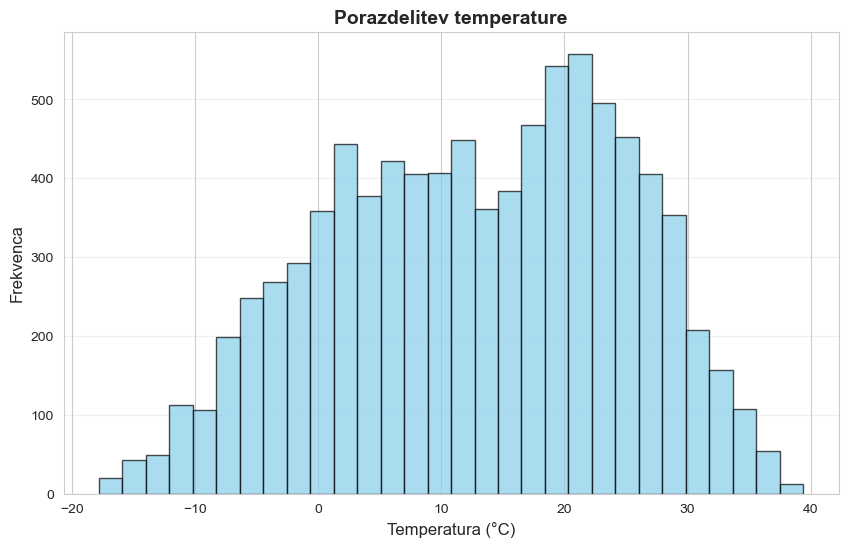

In [9]:
# 7. Histogram za spremenljivko "temperature"
plt.figure(figsize=(10, 6))
plt.hist(df['temperature'], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Temperatura (°C)', fontsize=12)
plt.ylabel('Frekvenca', fontsize=12)
plt.title('Porazdelitev temperature', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()


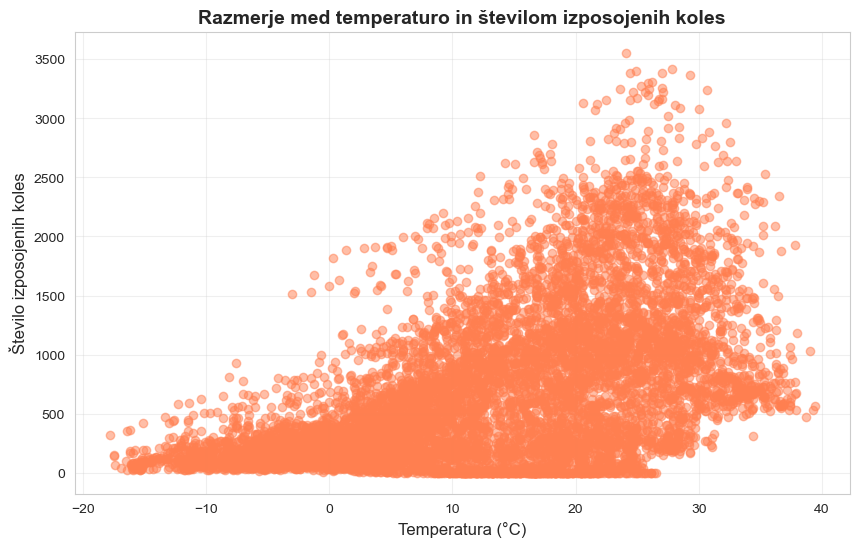

In [10]:
# 8. Graf raztrosa temperature in števila izposojenih koles
plt.figure(figsize=(10, 6))
plt.scatter(df['temperature'], df['rented_bike_count'], alpha=0.5, color='coral')
plt.xlabel('Temperatura (°C)', fontsize=12)
plt.ylabel('Število izposojenih koles', fontsize=12)
plt.title('Razmerje med temperaturo in številom izposojenih koles', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# 9. Razdelitev na učno in testno množico
X = df.drop('rented_bike_count', axis=1)
y = df['rented_bike_count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234
)

print(f"Velikost učne množice: {X_train.shape[0]} primerov")
print(f"Velikost testne množice: {X_test.shape[0]} primerov")
print(f"Odstotek testne množice: {(X_test.shape[0] / len(df)) * 100:.1f}%")


Velikost učne množice: 6132 primerov
Velikost testne množice: 2628 primerov
Odstotek testne množice: 30.0%


In [12]:
# 10. Gradnja napovednega modela z linearno regresijo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Model linearne regresije je zgrajen!")
print(f"Število koeficientov: {len(lr_model.coef_)}")


Model linearne regresije je zgrajen!
Število koeficientov: 20


In [17]:
# 11. Napovedi za testno množico
lr_predictions = lr_model.predict(X_test)

# 12. Izračun metrik
def calculate_mape(y_true, y_pred):
    mask = y_true != 0  # Izloči ničelne vrednosti
    if mask.sum() == 0:  # Če so vse vrednosti 0
        return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae_lr = mean_absolute_error(y_test, lr_predictions)
mape_lr = calculate_mape(y_test, lr_predictions)
mse_lr = mean_squared_error(y_test, lr_predictions)
evs_lr = explained_variance_score(y_test, lr_predictions)

print("=" * 50)
print("REZULTATI LINEARNE REGRESIJE")
print("=" * 50)
print(f"MAE (Mean Absolute Error): {mae_lr:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape_lr:.2f}%")
print(f"MSE (Mean Squared Error): {mse_lr:.2f}")
print(f"EVS (Explained Variance Score): {evs_lr:.4f}")
print("=" * 50)


REZULTATI LINEARNE REGRESIJE
MAE (Mean Absolute Error): 330.20
MAPE (Mean Absolute Percentage Error): 163.86%
MSE (Mean Squared Error): 193318.60
EVS (Explained Variance Score): 0.5542


In [18]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Napovedi
knn_predictions = knn_model.predict(X_test)

# Izračun metrik
mae_knn = mean_absolute_error(y_test, knn_predictions)
mape_knn = calculate_mape(y_test, knn_predictions)
mse_knn = mean_squared_error(y_test, knn_predictions)
evs_knn = explained_variance_score(y_test, knn_predictions)

print("=" * 50)
print("REZULTATI K-NEAREST NEIGHBORS")
print("=" * 50)
print(f"MAE (Mean Absolute Error): {mae_knn:.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape_knn:.2f}%")
print(f"MSE (Mean Squared Error): {mse_knn:.2f}")
print(f"EVS (Explained Variance Score): {evs_knn:.4f}")
print("=" * 50)


REZULTATI K-NEAREST NEIGHBORS
MAE (Mean Absolute Error): 306.06
MAPE (Mean Absolute Percentage Error): 118.75%
MSE (Mean Squared Error): 198208.72
EVS (Explained Variance Score): 0.5427


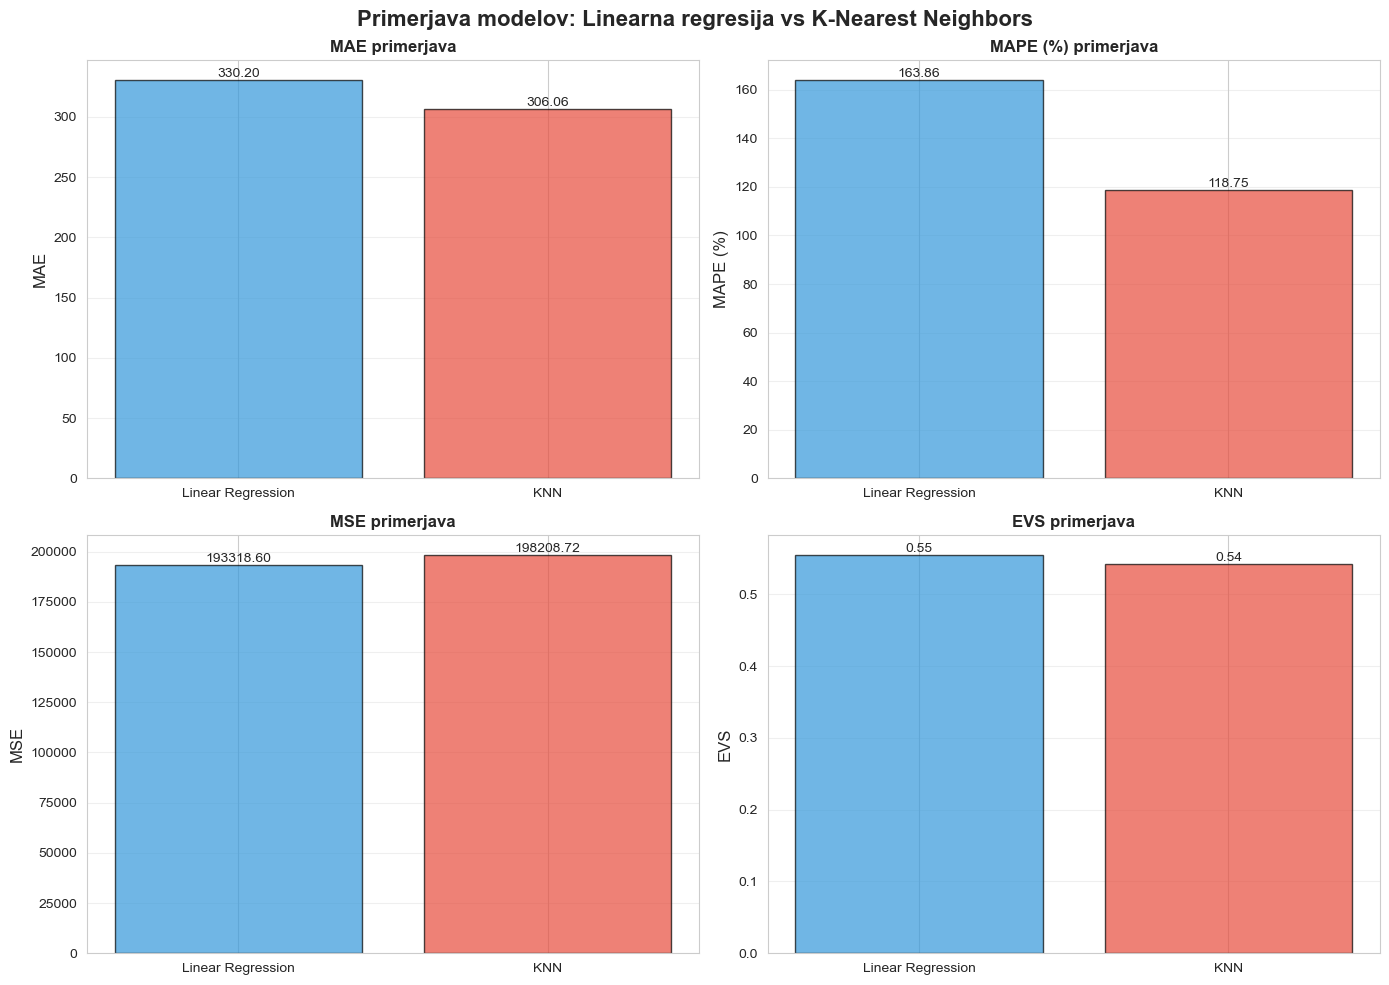

In [19]:
# Primerjava obeh modelov s stolpičnimi grafi
metrics_names = ['MAE', 'MAPE (%)', 'MSE', 'EVS']
lr_scores = [mae_lr, mape_lr, mse_lr, evs_lr]
knn_scores = [mae_knn, mape_knn, mse_knn, evs_knn]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Primerjava modelov: Linearna regresija vs K-Nearest Neighbors', 
             fontsize=16, fontweight='bold')

colors = ['#3498db', '#e74c3c']

for idx, ax in enumerate(axes.flat):
    metric_name = metrics_names[idx]
    values = [lr_scores[idx], knn_scores[idx]]
    
    bars = ax.bar(['Linear Regression', 'KNN'], values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_title(f'{metric_name} primerjava', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Dodajanje vrednosti na stolpce
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [16]:
# Povzetek primerjave
comparison_df = pd.DataFrame({
    'Metrika': ['MAE', 'MAPE (%)', 'MSE', 'EVS'],
    'Linear Regression': [mae_lr, mape_lr, mse_lr, evs_lr],
    'K-Nearest Neighbors': [mae_knn, mape_knn, mse_knn, evs_knn]
})

print("\nPOVZETEK PRIMERJAVE MODELOV:")
print(comparison_df.to_string(index=False))

# Določitev boljšega modela
if mae_lr < mae_knn:
    print(f"\n✓ Boljši model po MAE: Linear Regression ({mae_lr:.2f} < {mae_knn:.2f})")
else:
    print(f"\n✓ Boljši model po MAE: K-Nearest Neighbors ({mae_knn:.2f} < {mae_lr:.2f})")



POVZETEK PRIMERJAVE MODELOV:
 Metrika  Linear Regression  K-Nearest Neighbors
     MAE       3.301994e+02         3.060562e+02
MAPE (%)                inf                  inf
     MSE       1.933186e+05         1.982087e+05
     EVS       5.541983e-01         5.427355e-01

✓ Boljši model po MAE: K-Nearest Neighbors (306.06 < 330.20)
